# Active Lives 2016-17 — London EDA & Multi-Pillar Analysis (Wave 2)

Third processed wave, using the shared `active_lives_utils` module. Structure mirrors the
2022-23 baseline; only this wave's **config + codebook** differ. The differences below were
surfaced automatically by `validate_wave` and `compare_codebooks` — not assumed.

### How 2016-17 differs from the 2022-23 baseline (documented)
- **`health` is absent** — dropped from the regression and skipped as a breakdown.
- **`Eth7` code 3 = "South Asian"** here (vs "Asian excl. Chinese" in 2022-23) — same code,
  *different population*. Labelled wave-correctly; flagged for harmonisation.
- **`NSSEC5` has a 5th code = "Aged <16 or 75+"** (an age-exclusion, not a social group) —
  labelled as such; 2022-23 had only 4 codes.
- **Volunteering vars (`VolAny`, roles) carry no `.sav` value labels** — standard 0/1 labels
  applied manually. Data is present and usable.
- Activity middle band is officially "Insufficiently Active" here vs "Fairly Active" in 2022-23
  (cosmetic; code 2 = "Active" is identical, so all activity rates are comparable).

## 1. Imports & load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from active_lives_utils import (LONDON_LA2021, decode, london_filter,
                                weighted_share, weighted_distribution,
                                check_routing, validate_wave)

CSV = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y2_2016-17.csv"
df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique())

shape: (19248, 498) | year: ['2016-17']


## 2. Validate the wave (run before anything else)

In [2]:
validate_wave(df, "2016-17", expected_active=0.62)

=== validate_wave: 2016-17 -> PASS ===


[]

## 3. Codebook — 2016-17 specific (verified against this wave's .sav)

In [3]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01": {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "Gend3": {1: "Male", 2: "Female", 3: "Other"},
    # NOTE: code 3 = South Asian in 2016-17 (differs from 2022-23 'Asian excl. Chinese')
    "Eth7":  {1: "White British", 2: "White Other", 3: "South Asian",
              4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9": {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
             6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    # 5th code is an age-exclusion group, not a social class
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)", 4: "Students and other (NS-SEC 9)",
               5: "Aged <16 or 75+ (outside classification)"},
    "Educ6": {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
              4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "BMIG": {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese", 5: "Morbidly obese"},
    # Volunteering: no .sav labels in 2016-17, applied manually
    "VolAny": {0: "Did not volunteer", 1: "Volunteered"},
}
VOL_ROLES = {  # role names verified from 2022-23 .sav question text; same variables in 2016-17
    "volint1_vol": "Raising funds", "volint2_vol": "Providing transport",
    "volint3_vol": "Coaching/instructing", "volint4_vol": "Refereeing/officiating",
    "volint5_vol": "Administrative/committee role", "volint6_vol": "Stewarding/marshalling",
    "volint7_vol": "Other help",
}

CONFIG = {
    "weight":"wt_final", "la_code":"LA_2021",
    "activity_band":"MEMS7GR_SPORTCOUNT_A01",
    "activity_in":"MEMS7GR_IN_SPORTCOUNT_A01", "activity_out":"MEMS7GR_OUT_SPORTCOUNT_A01",
    "age":"Age9", "gender":"Gend3", "ethnicity":"Eth7", "disability":"Disab3",
    "nssec":"NSSEC5", "education":"Educ6", "bmi":"BMIG", "volunteer":"VolAny",
    # NOTE: no "health" — absent in 2016-17
}

## 4. Decode & build the London frame

In [4]:
df = df[df["Age9"] != 1.0].copy()             # drop 14-15 if present
data = decode(df, CONFIG, CODEBOOK)
london = london_filter(data, la_col="LA_2021")
assert london["LA_name"].nunique() in (31, 32), f"Unexpected borough count: {london['LA_name'].nunique()}"
print(f"London frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs")

London frame: 19,248 rows, 32 boroughs


## 5. Missingness & routing

In [5]:
concept_cols = [c for c in ["activity_band","activity_in","activity_out","age","gender",
    "ethnicity","disability","nssec","education","bmi","volunteer","weight"] if c in london.columns]
miss = (london[concept_cols].isna().mean()*100).round(1).sort_values(ascending=False)
print(miss.to_string())

# Routing checks (volunteer roles among volunteers; impairment among disabled)
role_cols = [c for c in london.columns if c.startswith("volint")]
if role_cols:
    check_routing(london, "volunteer", "Volunteered", role_cols, "Volunteer -> role detail")
disty = [c for c in london.columns if c.startswith("disty")]
if disty:
    check_routing(london, "disability", "Limiting disability", disty, "Limiting disability -> impairment")

activity_in      70.7
activity_out     70.7
volunteer        35.2
bmi              16.6
ethnicity         7.1
disability        6.3
education         3.6
age               1.2
gender            0.2
activity_band     0.0
nssec             0.0
weight            0.0
Volunteer -> role detail=='Volunteered' (n=2740): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment=='Limiting disability' (n=2477): max dep-missing=0.019, all-blank=48 (1.9%)


## 6. Pillar 1 — Participation

In [6]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2016-17): {overall:.3f}   (2015-16: 0.635 | 2022-23: 0.643)")
for f in ["age","gender","ethnicity","disability","nssec","education","bmi"]:
    if f in london.columns:
        print(f"\n=== % Active by {f} ===")
        print(weighted_share(london, [f], "activity_band", "Active").dropna(subset=[f]).to_string(index=False))

Overall London % Active (2016-17): 0.623   (2015-16: 0.635 | 2022-23: 0.643)

=== % Active by age ===
  age  weighted_share    n
16-24        0.699850 1568
25-34        0.672637 3545
35-44        0.637044 4005
45-54        0.645627 3291
55-64        0.599081 2816
65-74        0.563651 2471
75-84        0.359482 1016
  85+        0.223187  298

=== % Active by gender ===
gender  weighted_share     n
Female        0.601512 10959
  Male        0.645986  8243
 Other        0.000000     1

=== % Active by ethnicity ===
         ethnicity  weighted_share     n
             Black        0.540724  1301
           Chinese        0.552775   337
             Mixed        0.727092   512
Other ethnic group        0.591816   483
       South Asian        0.537089  2346
     White British        0.668731 10106
       White Other        0.661070  2806

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.445576  2477
          No disability     

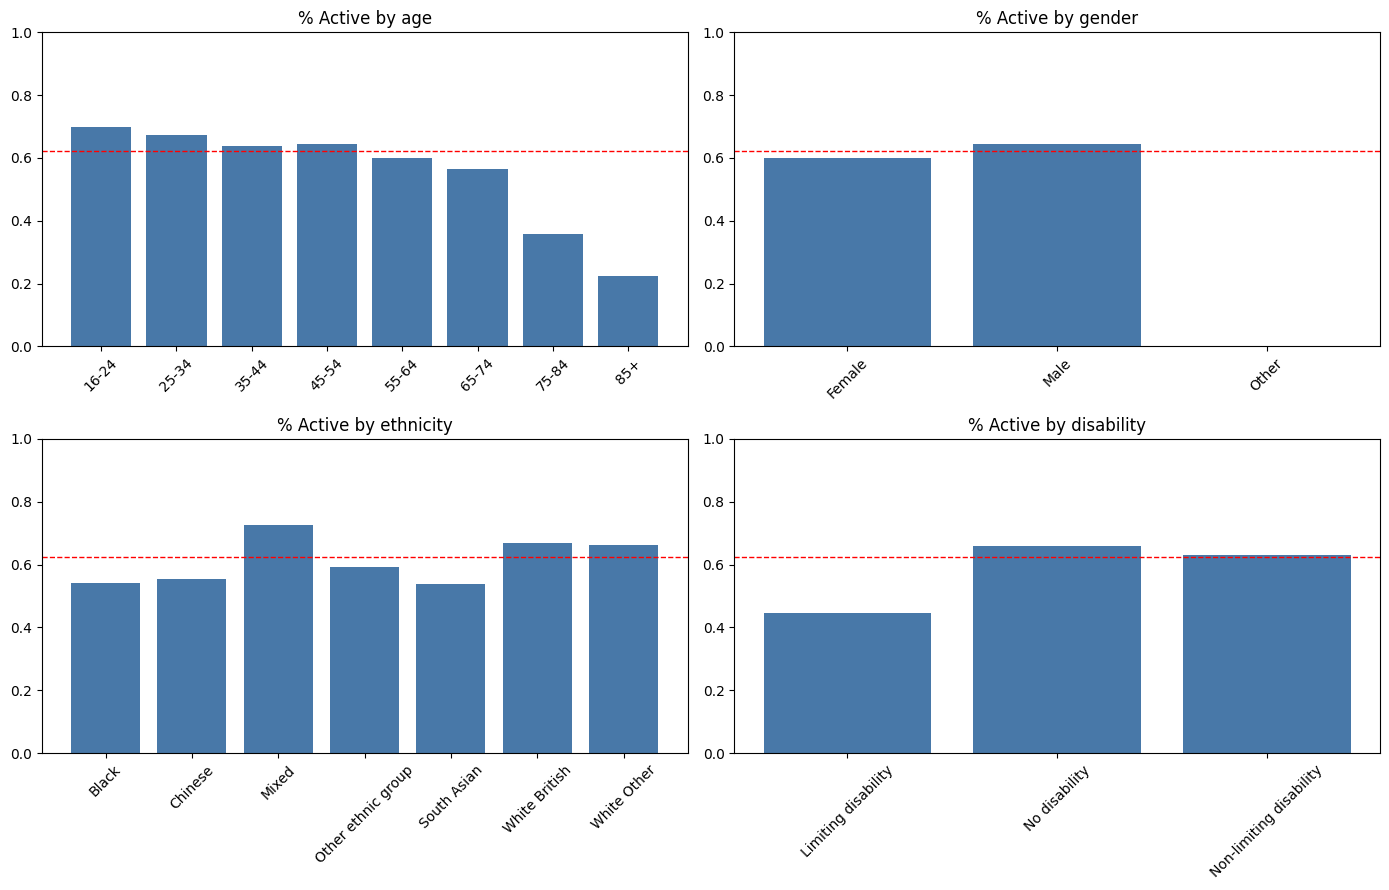

In [7]:
factors=["age","gender","ethnicity","disability"]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax,f in zip(axes.ravel(), factors):
    r = weighted_share(london, [f], "activity_band", "Active").dropna(subset=[f])
    ax.bar(r[f].astype(str), r["weighted_share"], color="#4878a8"); ax.set_ylim(0,1)
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_title(f"% Active by {f}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share    n
                Barnet        0.492306  958
                Harrow        0.527638  486
              Hounslow        0.530930  484
                Ealing        0.538402  492
                 Brent        0.558598  489
             Redbridge        0.561789  997
                Sutton        0.566350  499
                Bexley        0.567151  498
  Barking and Dagenham        0.567781  997
              Havering        0.573295  494
               Enfield        0.575115 1000
            Hillingdon        0.598354  494
              Lewisham        0.603307  485
               Croydon        0.606598  501
                Newham        0.619519  505
             Greenwich        0.622754  987
         Tower Hamlets        0.640645  479
              Haringey        0.642339  992
        Waltham Forest        0.645377  503
  Kingston upon Thames        0.656945  479
                Merton        0.658547  496
           Westminster        0.

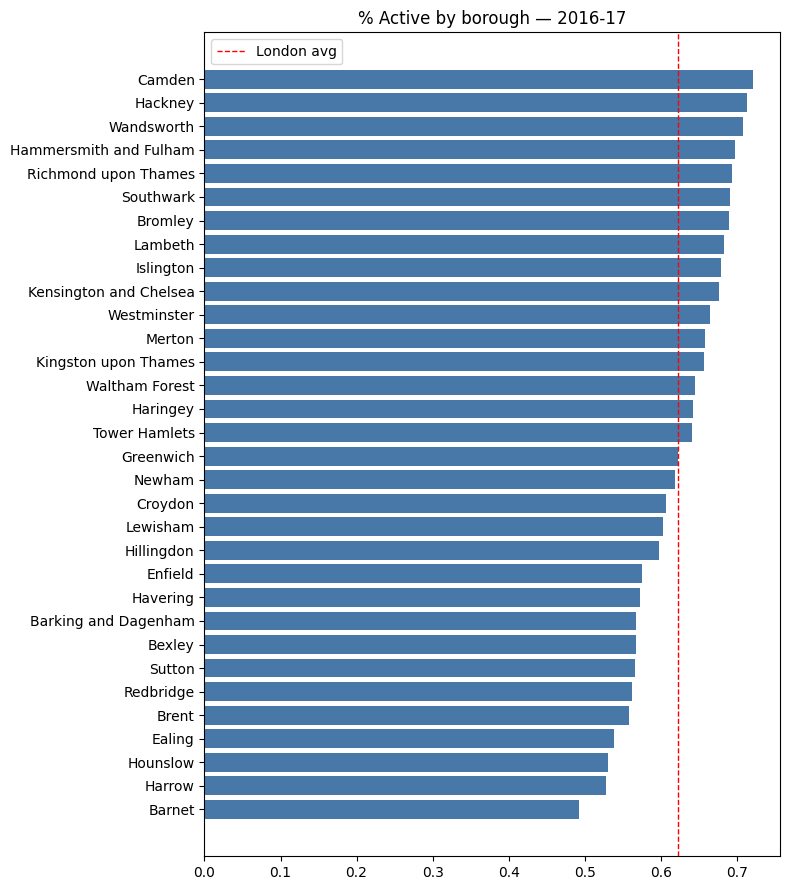

In [8]:
bor = weighted_share(london, ["LA_name"], "activity_band", "Active").sort_values("weighted_share")
print(bor.to_string(index=False))
fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_title("% Active by borough — 2016-17"); ax.legend(); plt.tight_layout(); plt.show()

## 7. Pillar 3 — Indoor vs Outdoor

In [9]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,}")
for place,col in [("Indoor","activity_in"),("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io, [], col, 'Active'):.3f}")

Indoor/outdoor base: 5,641 of 19,248
Indoor: weighted % active = 0.274
Outdoor: weighted % active = 0.538


## 8. Pillar 4 — Volunteering

In [10]:
volr = weighted_share(london, [], "volunteer", "Volunteered")
print(f"Overall weighted % volunteered: {volr:.3f}   (2022-23: 0.183)")
for f in ["age","gender","disability","nssec"]:
    if f in london.columns:
        print(f"\n=== % Volunteered by {f} ===")
        print(weighted_share(london, [f], "volunteer", "Volunteered").dropna(subset=[f]).to_string(index=False))

vols = london[london["volunteer"]=="Volunteered"].dropna(subset=["weight"]).copy()
role_share={}
for col,label in VOL_ROLES.items():
    if col in vols.columns:
        d=vols.dropna(subset=[col]); role_share[label]=(d[col]*d["weight"]).sum()/d["weight"].sum()
if role_share:
    print("\nVolunteer role mix:"); print(pd.Series(role_share).sort_values(ascending=False).round(3).to_string())

Overall weighted % volunteered: 0.229   (2022-23: 0.183)

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.290727  993
25-34        0.193386 2170
35-44        0.223967 2534
45-54        0.264222 2183
55-64        0.231746 1874
65-74        0.228136 1648
75-84        0.163854  697
  85+        0.125929  220

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.203485 7132
  Male        0.255473 5307

=== % Volunteered by disability ===
             disability  weighted_share    n
    Limiting disability        0.181273 1669
          No disability        0.237309 8356
Non-limiting disability        0.237343 1715

=== % Volunteered by nssec ===
                                   nssec  weighted_share    n
Aged <16 or 75+ (outside classification)        0.154512  917
       Higher social groups (NS-SEC 1-2)        0.250445 6948
        Lower social groups (NS-SEC 6-8)        0.156180 1209
       Middle social groups (NS-SEC 3-5)        0.223687

## 9. Pillar 2 — Regression (health dropped for this wave)

`health` is absent in 2016-17, so the model omits it. This means the disability coefficient is
**not** mediated by health here (unlike 2022-23), so expect limiting disability to show a stronger
independent effect — closer to the 2015-16 result. A genuine spec difference, not an error.

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
need=["activity_band","age","gender","disability","ethnicity","nssec","weight"]
m = london.dropna(subset=need).copy()
m["active"]=(m["activity_band"]=="Active").astype(int)
print(f"Complete-case sample: {len(m):,} of {len(london):,} ({len(m)/len(london):.0%})")
model = smf.glm('active ~ C(age) + C(gender, Treatment(reference="Female")) '
                '+ C(disability, Treatment(reference="No disability")) '
                '+ C(ethnicity, Treatment(reference="White British")) + C(nssec)',
                data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
or_table = pd.DataFrame({"odds_ratio":np.exp(model.params), "p_value":model.pvalues,
    "ci_low":np.exp(model.conf_int()[0]), "ci_high":np.exp(model.conf_int()[1])}).round(3)
print(or_table.to_string())

Complete-case sample: 16,913 of 19,248 (88%)
                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            1.799    0.000   1.674    1.934
C(age)[T.25-34]                                                                      0.659    0.000   0.591    0.734
C(age)[T.35-44]                                                                      0.590    0.000   0.527    0.661
C(age)[T.45-54]                                                                      0.596    0.000   0.530    0.670
C(age)[T.55-64]                                                                      0.498    0.000   0.441    0.564
C(age)[T.65-74]                                                                      0.365    0.000   0.319    0.417
C(age)[T.75-84]                                                                      0.438    0.000   0.390    0.492
C(age)[T.85+]      

## 10. Save

In [12]:
london.to_parquet("london_2016_17_clean.parquet")
print("saved london_2016_17_clean.parquet", london.shape)
print("Wave comparison (overall % active):")
print(pd.DataFrame({"wave":["2015-16","2016-17","2022-23"],
    "pct_active":[0.635, round(weighted_share(london,[],"activity_band","Active"),3), 0.643]}).to_string(index=False))

saved london_2016_17_clean.parquet (19248, 513)
Wave comparison (overall % active):
   wave  pct_active
2015-16       0.635
2016-17       0.623
2022-23       0.643


## Findings — to complete after running
- Overall active 2016-17: ___ (vs 2015-16 0.635, 2022-23 0.643).
- Borough range: ___ to ___.
- Volunteering: ___% (vs 2022-23 18.3%); top role ___.
- Regression: disability effect ___ (expected stronger than 2022-23 since health not controlled).

### Harmonisation flags for the panel
- Eth7 code 3 = South Asian (2016-17) vs Asian excl. Chinese (2022-23) — NOT directly comparable.
- NS-SEC has a 5th age-exclusion category in 2016-17 — map to common 1-4 before comparing.
- health unavailable in 2016-17 — any health-based analysis is 2022-23 only.